In [42]:
import pandas as pd

In [43]:
df=pd.read_csv("C:/Users/dhanush/OneDrive/Documents/asteroid_close_approaches_2015_2035 (1).csv")
df

,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude
0,0.045100,6746806,17.55,0.013778,0.076571,11.891749,42810,11.886780,28.39
1,0.048239,7216474,18.77,0.048220,0.048258,7.065686,25436,7.057864,25.30
2,0.026522,3967664,10.32,0.026522,0.026522,12.703378,45732,12.695467,20.63
3,0.079692,11921722,31.01,0.078275,0.081108,24.982094,89936,24.980756,24.16
4,0.010995,1644896,4.28,0.010971,0.011020,13.998882,50396,13.981561,23.40
...,...,...,...,...,...,...,...,...,...
27425,0.083559,12500228,32.52,0.066438,0.100799,8.709480,31354,8.705818,26.89
27426,0.089199,13343971,34.71,0.088964,0.141531,10.708675,38551,10.705885,23.54
27427,0.058551,8759067,22.79,0.058549,0.058552,1.831257,6593,1.806236,26.41
27428,0.024968,3735173,9.72,0.004201,0.046292,9.403958,33854,9.392603,26.86


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27430 entries, 0 to 27429
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   distance_au             27430 non-null  float64
 1   dist_km                 27430 non-null  int64  
 2   dist_lunar              27430 non-null  float64
 3   distance_min_au         27430 non-null  float64
 4   distance_max_au         27430 non-null  float64
 5   velocity_km_s           27430 non-null  float64
 6   v_rel_kmh               27430 non-null  int64  
 7   velocity_infinity_km_s  27413 non-null  float64
 8   absolute_magnitude      27422 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.9 MB


In [45]:
df.describe()

,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude
count,27430.000000,2.743000e+04,27430.000000,27430.000000,27430.000000,27430.000000,27430.000000,27413.000000,27422.000000
mean,0.043267,6.472706e+06,16.838332,0.040458,0.049533,10.556117,38002.023514,10.529040,25.454261
std,0.029518,4.415760e+06,11.487317,0.028642,0.040626,5.238803,18859.692068,5.244495,2.210958
min,0.000044,6.599000e+03,0.020000,0.000000,0.000044,0.138271,498.000000,0.036680,13.820000
25%,0.016782,2.510530e+06,6.530000,0.015043,0.017461,6.925957,24933.500000,6.897445,24.300000
50%,0.039475,5.905320e+06,15.365000,0.035934,0.042550,9.523842,34285.500000,9.493536,25.590000
75%,0.068108,1.018885e+07,26.510000,0.063576,0.074501,13.284721,47824.750000,13.259301,26.840000
max,0.099993,1.495878e+07,38.910000,0.099992,0.373051,40.190937,144687.000000,40.186533,34.060000


In [46]:
df.isnull().sum()

distance_au                0
dist_km                    0
dist_lunar                 0
distance_min_au            0
distance_max_au            0
velocity_km_s              0
v_rel_kmh                  0
velocity_infinity_km_s    17
absolute_magnitude         8
dtype: int64

In [47]:
df.dropna(inplace=True)

In [48]:
df.isnull().sum()

distance_au               0
dist_km                   0
dist_lunar                0
distance_min_au           0
distance_max_au           0
velocity_km_s             0
v_rel_kmh                 0
velocity_infinity_km_s    0
absolute_magnitude        0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.columns

Index(['distance_au', 'dist_km', 'dist_lunar', 'distance_min_au',
       'distance_max_au', 'velocity_km_s', 'v_rel_kmh',
       'velocity_infinity_km_s', 'absolute_magnitude'],
      dtype='object')

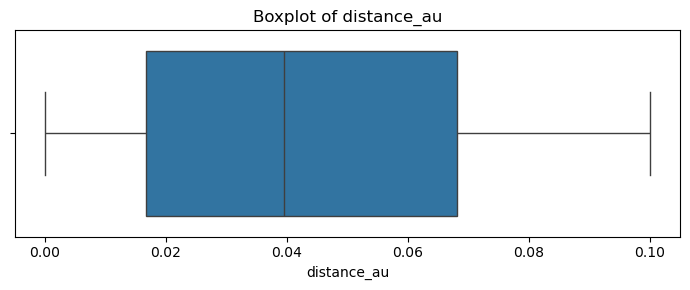

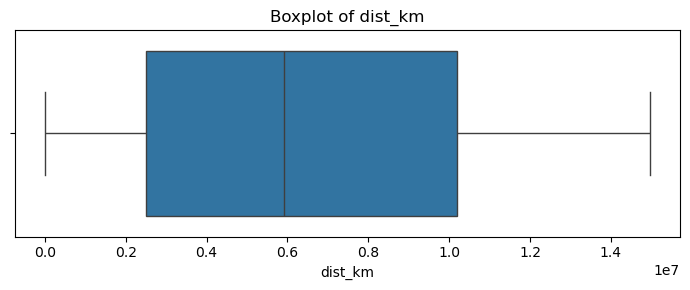

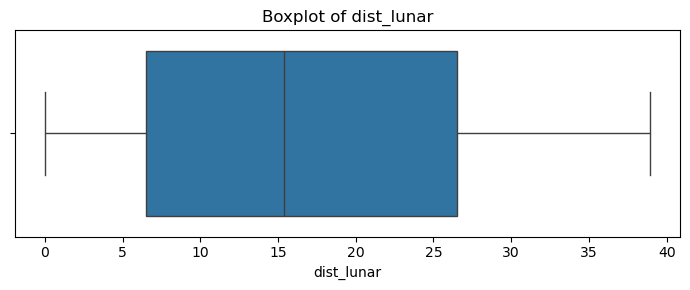

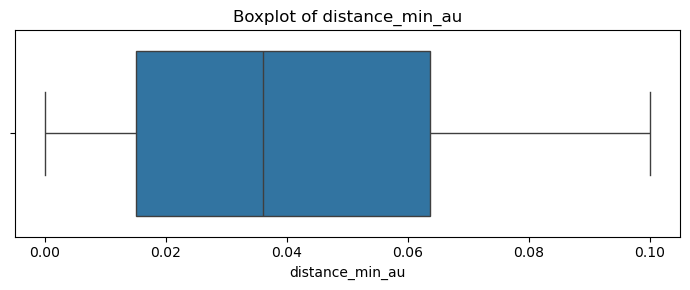

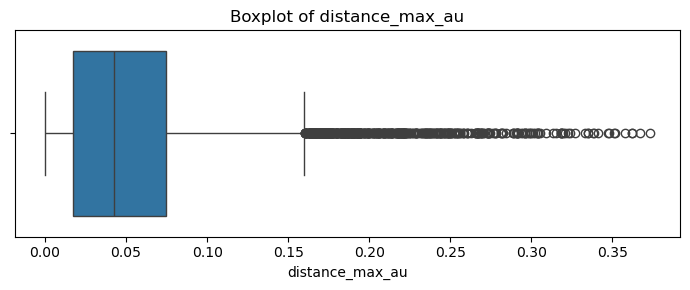

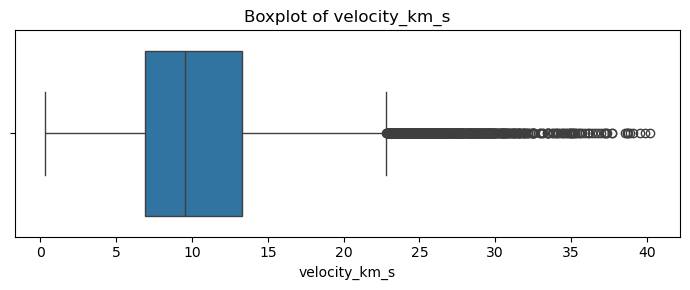

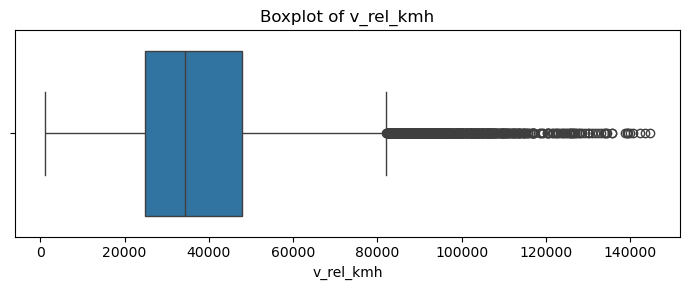

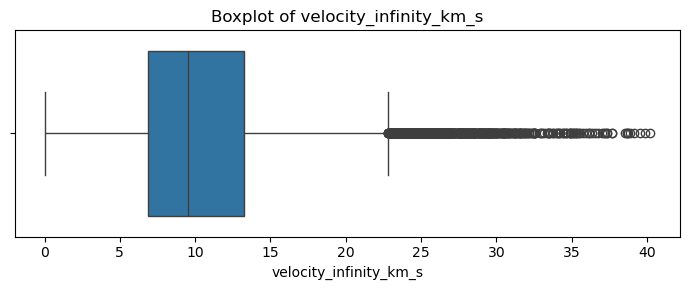

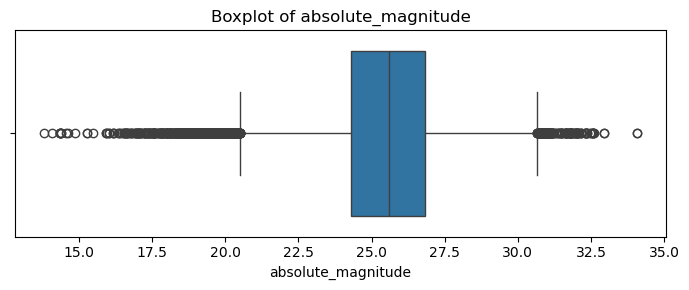

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'distance_au',
    'dist_km',
    'dist_lunar',
    'distance_min_au',
    'distance_max_au',
    'velocity_km_s',
    'v_rel_kmh',
    'velocity_infinity_km_s',
    'absolute_magnitude'
]

for col in cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

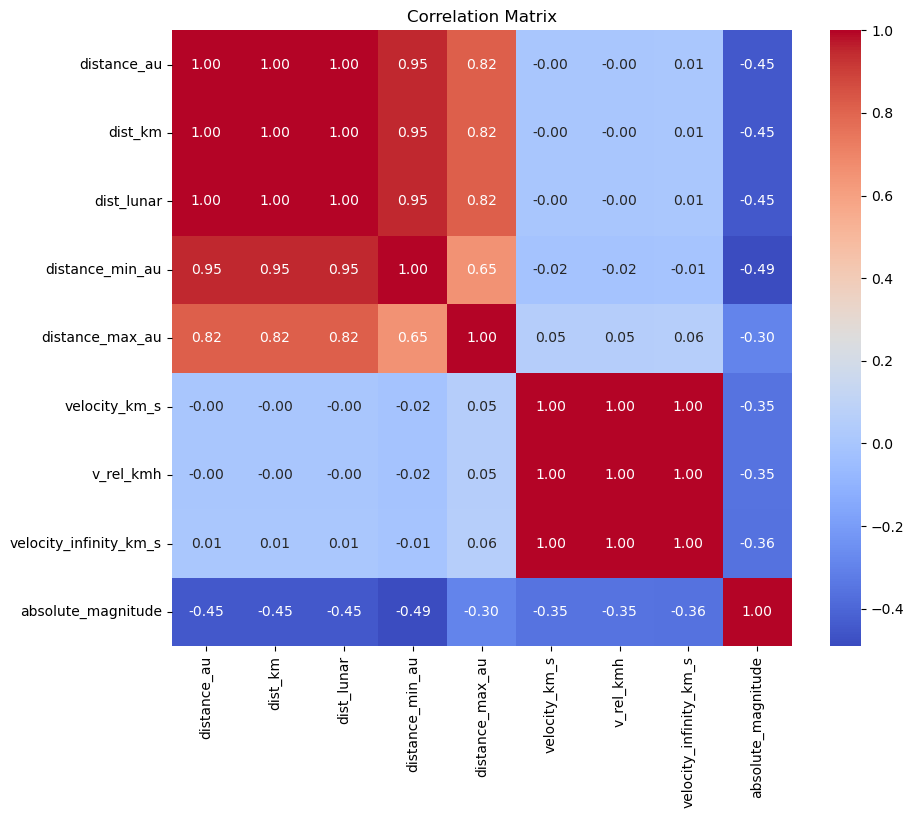

In [52]:
plt.figure(figsize=(10,8))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [53]:
df.drop(['dist_km', 'dist_lunar', 'v_rel_kmh'], axis=1, inplace=True)

In [54]:
y = df['absolute_magnitude']

In [55]:
x= df.drop('absolute_magnitude', axis=1)


In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = x.select_dtypes(include='object').columns
for col in cat_cols:
    x[col] = x[col].astype(str)  
    x[col] = le.fit_transform(x[col])

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 34)

In [58]:
x_train.shape

(21924, 5)

In [59]:
x_test.shape

(5481, 5)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
x_train_scaled = scaler.fit_transform(x_train)

In [22]:
x_test_scaled = scaler.transform(x_test)

In [22]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()

In [23]:
lr.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred=lr.predict(x_test_scaled)

In [25]:
from sklearn.metrics import(r2_score)
r2=r2_score(y_test,y_pred)

In [26]:
r2

0.4028470997164778

In [27]:
test_score =lr.score(x_test_scaled,y_test)
test_score

0.4028470997164778

In [28]:
train_score=lr.score(x_train_scaled,y_train)
train_score

0.39667535448733005

In [29]:
lr_pred = lr.predict(x_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

MAE : 1.2194729439839922
MSE : 2.8389926758629476
RMSE: 1.6849310596766112


In [30]:
from sklearn.svm import SVR
svr = SVR()

In [31]:
svr.fit(x_train_scaled,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [32]:
y_pred_svr= svr.predict(x_test_scaled)

In [33]:
from sklearn.metrics import(r2_score)
import numpy as np
r2=r2_score(y_test,y_pred_svr)
r2

0.4832623129582684

In [34]:
train_score_svr=svr.score(x_train_scaled,y_train)
train_score_svr

0.49239519521967623

In [35]:
test_score_svr=svr.score(x_test_scaled,y_test)
test_score_svr

0.4832623129582684

In [36]:
svr_pred = svr.predict(x_test_scaled)

print("MAE :", mean_absolute_error(y_test, svr_pred))
print("MSE :", mean_squared_error(y_test, svr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, svr_pred)))

MAE : 1.1281741331003807
MSE : 2.4566815436336533
RMSE: 1.5673804718809192


In [37]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()

In [38]:
knn.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
y_pred_knn = knn.predict(x_test_scaled)

In [40]:
from sklearn.metrics import(r2_score)
import numpy as np
r2=r2_score(y_test,y_pred_knn)
r2

0.41818212123425025

In [41]:
train_score_knn = knn.score(x_train_scaled,y_train)
train_score_knn

0.6098282909438884

In [42]:
test_score_knn = knn.score(x_test_scaled,y_test)
test_score_knn

0.41818212123425025

In [43]:
knn_pred = knn.predict(x_test_scaled)

print("MAE :", mean_absolute_error(y_test, knn_pred))
print("MSE :", mean_squared_error(y_test, knn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pred)))

MAE : 1.2487847473088853
MSE : 2.766086701944901
RMSE: 1.6631556457364118


In [75]:
from sklearn.model_selection import GridSearchCV
params_grid = {
    "n_neighbors":[3,5,7,9,11],
    "metric":["euclidean","manhattan"],
}
new_model= GridSearchCV(KNeighborsRegressor(),params_grid, cv=5)

new_model.fit(x_train_scaled,y_train)
print(new_model.best_params_)

{'metric': 'euclidean', 'n_neighbors': 11}


In [77]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(metric= 'euclidean', n_neighbors= 11)

In [78]:
knn.fit(x_train_scaled,y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [79]:
y_pred_knn = knn.predict(x_test_scaled)

In [80]:
r2=r2_score(y_test,y_pred_knn)
r2

0.45821414404281946

In [81]:
train_score_knn = knn.score(x_train_scaled,y_train)
train_score_knn

0.5514264550626051

In [82]:
test_score_knn = knn.score(x_test_scaled,y_test)
test_score_knn

0.45821414404281946

In [83]:
knn_pred = knn.predict(x_test_scaled)

print("MAE :", mean_absolute_error(y_test, knn_pred))
print("MSE :", mean_squared_error(y_test, knn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pred)))

MAE : 1.1941613839544873
MSE : 2.575765898848162
RMSE: 1.604919281100505


In [44]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()

In [45]:
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [46]:
y_pred_dt=dt.predict(x_test)

In [47]:
from sklearn.metrics import(r2_score)
import numpy as np
r2=r2_score(y_test,y_pred_dt)
r2

0.0749712285565094

In [48]:
train_score_dt = dt.score(x_train,y_train)
train_score_dt

1.0

In [49]:
test_score_dt = dt.score(x_test,y_test)
test_score_dt

0.0749712285565094

In [50]:
dt_pred = dt.predict(x_test)

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

MAE : 1.5471917533296842
MSE : 4.397784731253421
RMSE: 2.097089585891223


In [87]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
dt=DecisionTreeRegressor()
param={
    'max_depth':[5,10,15,20,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
random=RandomizedSearchCV(
    estimator=dt,
    param_distributions=param,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)
random.fit(x_train,y_train)
best_model=random.best_estimator_
y_pred=best_model.predict(x_test)
print("Best Parameters:",random.best_params_)

Best Parameters: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 5}


In [88]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(min_samples_split=10, min_samples_leaf= 4, max_depth= 5)

In [89]:
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [90]:
y_pred_dt=dt.predict(x_test)

In [91]:
r2=r2_score(y_test,y_pred_dt)
r2

0.4325395688429401

In [92]:
train_score_dt = dt.score(x_train,y_train)
train_score_dt

0.4516578850286539

In [93]:
test_score_dt = dt.score(x_test,y_test)
test_score_dt

0.4325395688429401

In [94]:
dt_pred = dt.predict(x_test)

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

MAE : 1.2179822904091462
MSE : 2.697828323586856
RMSE: 1.6425067194951914


In [23]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint, uniform
import numpy as np

# Create XGBoost model
xgb = XGBRegressor(random_state=42)

# Hyperparameter space
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit model
random_search.fit(x_train, y_train)

# Best model
best_xgb = random_search.best_estimator_

# Prediction
y_pred_xgb = best_xgb.predict(x_test)

# Metrics
train_score = best_xgb.score(x_train, y_train)
test_score = best_xgb.score(x_test, y_test)
r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

# Results
print("Best Parameters:", random_search.best_params_)
print("Train Score :", train_score)
print("Test Score  :", test_score)
print("R2 Score    :", r2)
print("MAE         :", mae)
print("MSE         :", mse)
print("RMSE        :", rmse)

Best Parameters: {'colsample_bytree': np.float64(0.7599443886861021), 'learning_rate': np.float64(0.023999698964084628), 'max_depth': 6, 'n_estimators': 370, 'subsample': np.float64(0.7824279936868144)}
Train Score : 0.582472817229982
Test Score  : 0.51724913005469
R2 Score    : 0.51724913005469
MAE         : 1.1096076606259122
MSE         : 2.295100942138085
RMSE        : 1.514959056257985


In [2]:
import pandas as pd

# Final Regression Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVR",
        "KNN",
        "Decision Tree",
        "XGBoost"
    ],

    "Train R²": [
        0.397,
        0.492,
        0.551,
        0.452,
        0.582
    ],

    "Test R²": [
        0.403,
        0.483,
        0.458,
        0.433,
        0.517
    ],

    "MAE": [
        1.219,
        1.128,
        1.194,
        1.218,
        1.110
    ],

    "MSE": [
        2.839,
        2.457,
        2.576,
        2.698,
        2.295
    ],

    "RMSE": [
        1.685,
        1.567,
        1.605,
        1.643,
        1.515
    ]
})

# Calculate Train-Test Gap
comparison["Gap"] = (
    comparison["Train R²"] -
    comparison["Test R²"]
).abs().round(3)

# Generalization status
comparison["Generalization"] = [
    "Well Generalized",
    "Best Generalized ⭐",
    "Overfitting",
    "Well Generalized",
    "Slight Overfit"
]

# Bias-Variance interpretation
comparison["Bias-Variance"] = [
    "Balanced",
    "Balanced",
    "High Variance",
    "Balanced",
    "Moderate Variance"
]

# Best Generalized Model
comparison["Best Generalized Model"] = [
    "No",
    "YES ⭐",
    "No",
    "No",
    "No"
]

# Display final table
comparison

,Model,Train R²,Test R²,MAE,MSE,RMSE,Gap,Generalization,Bias-Variance,Best Generalized Model
0,Linear Regression,0.397,0.403,1.219,2.839,1.685,0.006,Well Generalized,Balanced,No
1,SVR,0.492,0.483,1.128,2.457,1.567,0.009,Best Generalized ⭐,Balanced,YES ⭐
2,KNN,0.551,0.458,1.194,2.576,1.605,0.093,Overfitting,High Variance,No
3,Decision Tree,0.452,0.433,1.218,2.698,1.643,0.019,Well Generalized,Balanced,No
4,XGBoost,0.582,0.517,1.110,2.295,1.515,0.065,Slight Overfit,Moderate Variance,No
